In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

data = pd.DataFrame({
    "R&D_Spend": np.random.randint(50000, 500000, n),
    "Employee_Count": np.random.randint(10, 1000, n),
    "Cloud_Adoption": np.random.choice([0, 1], n),
    "AI_Integration": np.random.choice([0, 1], n),
    "Cybersecurity_Score": np.random.randint(50, 100, n),
    "Market_Region": np.random.choice(["US", "EU", "Asia"], n),
    "Revenue": np.random.randint(100000, 2000000, n),
    "Success": np.random.choice([0, 1], n)  # Target variable
})

data.to_csv("ImaginaryTechnology.csv", index=False)
data.head()

,R&D_Spend,Employee_Count,Cloud_Adoption,AI_Integration,Cybersecurity_Score,Market_Region,Revenue,Success
0,171958,792,1,0,81,US,964645,1
1,196867,63,0,1,84,EU,1528127,1
2,181932,453,1,0,88,EU,1035772,0
3,415838,622,1,1,95,US,571082,1
4,309178,273,0,0,78,Asia,160545,1


In [2]:
df = pd.read_csv("ImaginaryTechnology.csv")
df.head()

,R&D_Spend,Employee_Count,Cloud_Adoption,AI_Integration,Cybersecurity_Score,Market_Region,Revenue,Success
0,171958,792,1,0,81,US,964645,1
1,196867,63,0,1,84,EU,1528127,1
2,181932,453,1,0,88,EU,1035772,0
3,415838,622,1,1,95,US,571082,1
4,309178,273,0,0,78,Asia,160545,1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical variable
le = LabelEncoder()
df["Market_Region"] = le.fit_transform(df["Market_Region"])

# Features & target
X = df.drop("Success", axis=1)
y = df["Success"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.55
              precision    recall  f1-score   support

           0       0.54      0.55      0.55        49
           1       0.56      0.55      0.55        51

    accuracy                           0.55       100
   macro avg       0.55      0.55      0.55       100
weighted avg       0.55      0.55      0.55       100



In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.47
              precision    recall  f1-score   support

           0       0.45      0.35      0.39        49
           1       0.48      0.59      0.53        51

    accuracy                           0.47       100
   macro avg       0.47      0.47      0.46       100
weighted avg       0.47      0.47      0.46       100



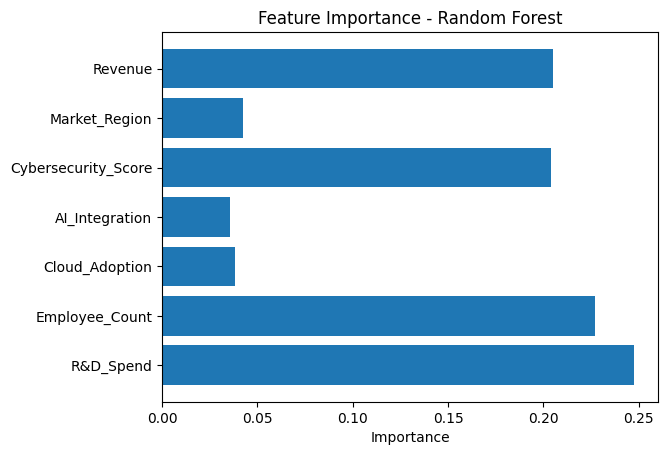

In [6]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()

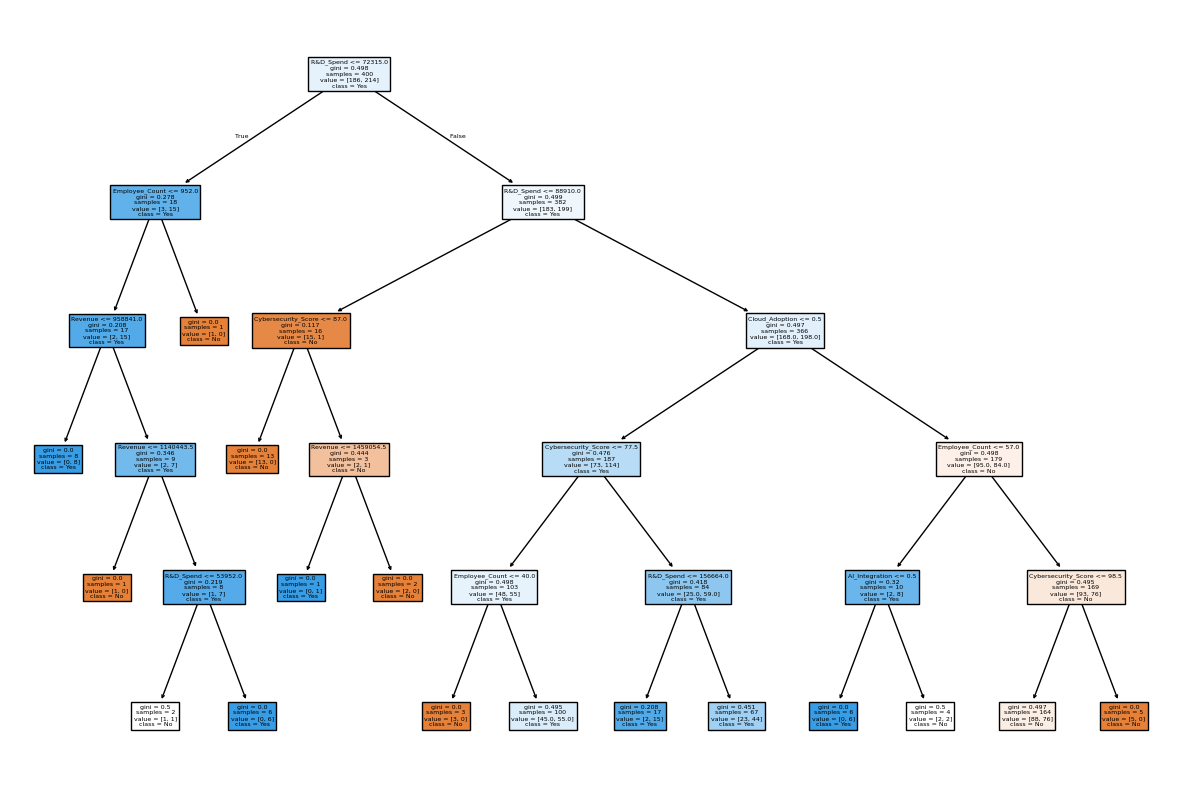

In [7]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.show()